### 4. Понятие embedding

Результаты прошлой сети оказались посредственными, потому что модель не воспринимает семантику слов, они кодируются лишь one-hot вектором, связь между слов и их типичный контекст не учитывается вовсе. К тому же, модель предсказывала отдельные символы, а не слова, которые как раз являются смысловой единицей предложения.

### 5. Способы получения embedding

Один из первых подходов формирования компактного векторного представления слов известен еще до времен активного применения нейронных сетей. Брался реальный текст и для каждого центрального слова оценивался его контекст. Часто это были два предыдущих и два следующих слова. В таблице для каждого центрального слова запоминалось число вхождений различных уникальных слов, попадающих в его контекст. 

Полученные векторы уже лучше отражали близость слов, чем простое one-hot кодирование. Но размеры этих векторов все еще равны размеру словаря. Для сокращения их размеров и сохранения сформированной информации можно применить один из известных методов сокращения размерности, например, алгоритмы PCA (метод главных компонент) или SVD (сингулярное разложение матриц).

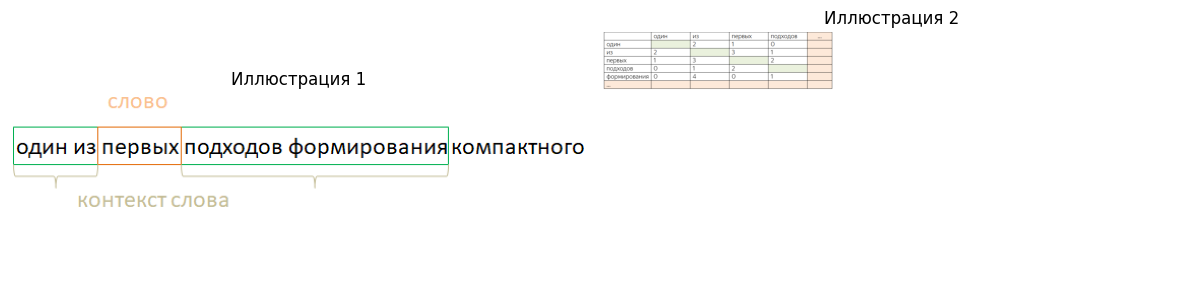

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image1 = mpimg.imread('illustrations/RNN_Word_2_Vec.png')
image2 = mpimg.imread('illustrations/RNN_Word_2_Vec_table.png')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(image1)
ax1.axis('off')
ax1.set_title('Иллюстрация 1')

ax2.imshow(image2)
ax2.axis('off')
ax2.set_title('Иллюстрация 2')

plt.tight_layout()
plt.show()

На вход обычной полносвязной НС подается слово, закодированное с помощью one-hot вектора. То есть, число входов соответствует размеру словаря. Далее, идет скрытый слой с линейной функцией активации, как правило, с много меньшим числом m нейронов, чем размер словаря. А затем, выходной слой по размерам в точности равный входному. При подаче очередного слова на выходе требуется получить все слова из его контекста. То есть, два предыдущих и два следующих после него слова. Причем, процесс обучения для каждого центрального слова выполняют следующим образом. 

Пусть в нашем примере подается слово «первых». Его контекст состоит из двух предыдущих слов «один», «из» и двух последующих «подходов», «формирования». Поэтому сначала обучаем его на получение первого слова из контекста «один», затем, на второе «из» и так по порядку для всех четырех слов. В результате сеть должна обучиться так, чтобы слова из контекста этого слова были наиболее вероятными (формировались наибольшие значения на соответствующих выходах сети). Такой подход обучения контекста по центральному слову получил название skip-gram. Существует и противоположный подход CBOW, когда делается прогноз центрального слова по его контексту. Оба метода приводят к примерно одинаковым результатам эмбеддинга.

После обучения сети строки матрицы $W$ можно рассматривать, как embedding соответствующих слов.

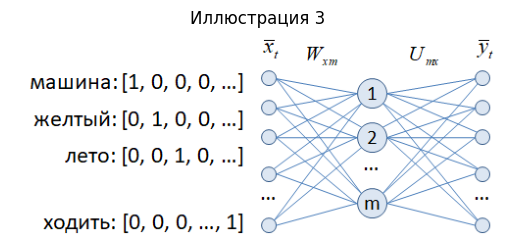

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image3 = mpimg.imread('illustrations/RNN_NN_embedding.png')

plt.imshow(image3)
plt.axis('off')
plt.title('Иллюстрация 3')
plt.show()

На просторах интернета можно найти обученные векторные представления слов. В частности, по ссылке: https://github.com/natasha/natasha можно перейти на страницу проекта «Наташа», который посвящен обработке естественного русского языка. Здесь же в описании сказано, что для его использования нужно выполнить установку этого пакета с помощью команды:

```
pip install natasha
```

Далее, в самом низу этой страницы есть ссылки на отдельные модули этого пакета. Нас интересует модуль Navec, отвечающий за embedding: https://github.com/natasha/navec

In [3]:
from navec import Navec
 
path = 'weights/embeddings_navec/navec_hudlit_v1_12B_500K_300d_100q.tar'
navec = Navec.load(path)

# Можно получить embedding-вектор почти любого русского слова
vec = navec['машина']

# Также можно проверить наличие слова в словаре
'машина' in navec

# И получить порядковый номер слова в словаре navec
indx = navec.vocab['автомобиль']

Далее, необходимо создать класс датасета в pytorch:

In [4]:
import re
import torch.utils.data as data
import torch

class WordsDataset(data.Dataset):
    def __init__(self, path, navec_emb, prev_words=3):
        self.prev_words = prev_words
        self.navec_emb = navec_emb
 
        with open(path, 'r', encoding='utf-8') as f:
            self.text = f.read()
            self.text = self.text.replace('\ufeff', '') # убираем первый невидимый символ
            self.text = self.text.replace('\n', ' ')
            self.text = re.sub(r'[^А-яA-z- ]', '', self.text) # удаляем все неразрешенные символы
 
        self.words = self.text.lower().split()
        self.words = [word for word in self.words if word in self.navec_emb] # оставляем слова, которые есть в словаре
        vocab = set(self.words)
 
        self.int_to_word = dict(enumerate((vocab)))
        self.word_to_int = {b: a for a, b in self.int_to_word.items()}
        self.vocab_size = len(vocab)
 
    def __getitem__(self, item):
        _data = torch.vstack([torch.tensor(self.navec_emb[self.words[x]]) for x in range(item, item+self.prev_words)])
        word = self.words[item+self.prev_words]
        t = self.word_to_int[word]
        return _data, t
 
    def __len__(self):
        return len(self.words) - 1 - self.prev_words

In [5]:
import torch.nn as nn

class WordsRNN(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.hidden_size = 256
        self.in_features = in_features
        self.out_features = out_features
 
        self.rnn = nn.RNN(in_features, self.hidden_size, batch_first=True)
        self.out = nn.Linear(self.hidden_size, out_features)
 
    def forward(self, x):
        x, h = self.rnn(x)
        y = self.out(h)
        return y

In [6]:
path = 'weights/embeddings_navec/navec_hudlit_v1_12B_500K_300d_100q.tar'
navec = Navec.load(path)

d_train = WordsDataset('datasets/rnn/train_data_true', navec, prev_words=3)
train_data = data.DataLoader(d_train, batch_size=8, shuffle=False)
 
model = WordsRNN(300, d_train.vocab_size)

In [7]:
from tqdm import tqdm
import torch.optim as optim

optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=0.0001)
loss_func = nn.CrossEntropyLoss()
 
epochs = 20
width = len(str(epochs))
model.train()

for _e in range(epochs):
    loss_mean = 0
    lm_count = 0
 
    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        predict = model(x_train).squeeze(0)
        loss = loss_func(predict, y_train.long())
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f'Epoch [{_e+1:>{width}d}/{epochs}], loss_mean={loss_mean:.3f}')

st = model.state_dict()
torch.save(st, 'weights/rnn/model_rnn.tar')

Epoch [20/20], loss_mean=0.057: 100%|██████████| 124/124 [00:01<00:00, 120.51it/s]


In [8]:
model.eval()
predict = "подумал встал и снова лег".lower().split()
total = 10
 
for _ in range(total):
    _data = torch.vstack([torch.tensor(d_train.navec_emb[predict[-x]]) for x in range(d_train.prev_words, 0, -1)])
    p = model(_data.unsqueeze(0)).squeeze(0)
    indx = torch.argmax(p, dim=1)
    predict.append(d_train.int_to_word[indx.item()])
 
print(" ".join(predict))

подумал встал и снова лег положительных возможностях подумай как много ты можешь сделать победители в
